In [12]:
import os 
os.chdir('D:/Astro/data for astroproject 2')
import pandas as pd 
df = pd.read_csv('IceAge_Complete_Catalogue_V12_Mar24.csv')

In [13]:
df.head(20)

,Unnamed: 0,ID,RA,Dec,F150W_Detection,F200W_Detection,F410M_Detection,F430M_Detection,F182M_Detection,F140M_Detection,...,CO2_detection,CO2_fittingstrategy,CO2_baseline,CO_detection,CO_fittingstrategy,CO_baseline,interesting_source,H2O_Notes,CO2_Notes,CO_Notes
0,0,0,166.470028,-77.422419,True,True,True,True,True,False,...,W,0,0,W,0,0,NaN,NaN,NaN,NaN
1,1,1,166.501921,-77.422258,True,True,True,True,True,False,...,x,0,0,x,0,0,NaN,NaN,NaN,NaN
2,2,2,166.506172,-77.421543,True,True,True,False,True,False,...,x,0,0,x,0,0,NaN,NaN,NaN,NaN
3,3,3,166.480625,-77.420300,True,True,True,True,True,True,...,S,U,0,W,0,0,NaN,NaN,NaN,NaN
4,4,4,166.465019,-77.419067,True,True,True,True,True,False,...,W,0,0,W,0,0,NaN,NaN,NaN,NaN
5,5,5,166.467896,-77.418083,True,True,True,True,True,True,...,W,0,0,W,0,0,NaN,NaN,NaN,NaN
6,6,6,166.627643,-77.417483,True,True,True,True,True,False,...,W,0,0,W,0,0,NaN,NaN,NaN,NaN
7,7,7,166.484728,-77.417211,True,True,True,True,True,True,...,N,0,FFM,W,0,0,NaN,NaN,"Weak, avg points? Fit BL and feat?",NaN
8,8,8,166.541231,-77.417218,True,True,True,True,False,True,...,D,0,M,D,0,M,NaN,NaN,R,R
9,9,9,166.622311,-77.416251,True,True,True,True,True,True,...,W,0,0,W,0,0,NaN,Bright - fit as U,NaN,NaN


In [14]:
import pandas as pd
import numpy as np

# 1. Load the massive master catalogue
df = pd.read_csv('IceAge_Complete_Catalogue_V12_Mar24.csv')

# 2. Select strictly the columns you need for the cospatial maps
columns_to_keep = ['ID', 'RA', 'Dec', 'H2O_N', 'CO2_N', 'CO_N']
clean_df = df[columns_to_keep].copy()

# 3. Convert the Scientific Notation Strings to actual Math Numbers
# The 'coerce' command is crucial—it automatically turns any broken text or missing data into NaN (Not a Number)
clean_df['H2O_N'] = pd.to_numeric(clean_df['H2O_N'], errors='coerce')
clean_df['CO2_N'] = pd.to_numeric(clean_df['CO2_N'], errors='coerce')
clean_df['CO_N'] = pd.to_numeric(clean_df['CO_N'], errors='coerce')

# 4. Clean the Spatial Coordinates
# Drop any row that is missing its physical location (RA and Dec)
clean_df = clean_df.dropna(subset=['RA', 'Dec'])

# 5. Drop the "Empty" Ice Rows
# Drop any row where ALL THREE ice column densities are completely empty/NaN
clean_df = clean_df.dropna(subset=['H2O_N', 'CO2_N', 'CO_N'], how='all')

# 6. Drop the "Zero" Ice Rows
# Filter out any lingering stars that technically have a measurement, but the measurement is zero
clean_df = clean_df[
    (clean_df['H2O_N'] > 0) | 
    (clean_df['CO2_N'] > 0) | 
    (clean_df['CO_N'] > 0)
]

# 7. Print out the final shape to confirm it worked!
print(f"Original messy dataset: {df.shape[0]} rows.")
print(f"Clean cospatial dataset: {clean_df.shape[0]} rows.")

# 8. Export the clean dataset as a brand new file
clean_df.to_csv('Cleaned_Cospatial_Catalogue.csv', index=False)
print("Saved successfully as 'Cleaned_Cospatial_Catalogue.csv'!")

Original messy dataset: 3433 rows.
Clean cospatial dataset: 497 rows.
Saved successfully as 'Cleaned_Cospatial_Catalogue.csv'!


In [17]:
import pandas as pd 
import os 
os.chdir('C:/Users/User/Downloads')
df = pd.read_csv('CSV_for_fig2.csv')
df.sample(10)

,ID,RA,Dec,H2O_N,CO2_N,CO_N
471,2193,166.403384,-77.399617,NaN,1.890000e+17,8.000000e+16
332,1960,166.344477,-77.433098,NaN,2.590000e+17,5.750000e+17
105,135,166.643980,-77.412261,4.850000e+18,3.900000e+17,NaN
268,805,166.696694,-77.362128,2.950000e+18,NaN,NaN
262,759,166.625669,-77.333027,6.580000e+17,NaN,NaN
463,2178,166.393650,-77.401810,NaN,4.770000e+17,8.000000e+16
25,34,166.525725,-77.407343,7.100000e+18,9.000000e+17,1.040000e+18
92,120,166.508442,-77.410848,NaN,9.060000e+17,1.650000e+18
233,697,166.787939,-77.347203,1.790000e+18,NaN,NaN
366,2031,166.448672,-77.421803,NaN,1.000000e+16,NaN


In [22]:
df2 = df = df.fillna(0)

In [19]:
import pandas as pd
import numpy as np
import os 
os.chdir('D:/Astro/data for astroproject 2')
# 1. Load the massive master catalogue
df = pd.read_csv('IceAge_Complete_Catalogue_V12_Mar24.csv')

# 2. Select strictly the columns you need for the cospatial maps
columns_to_keep = ['ID', 'RA', 'Dec', 'H2O_N', 'CO2_N', 'CO_N']
clean_df = df[columns_to_keep].copy()

# 3. Convert the Scientific Notation Strings to actual Math Numbers
# The 'coerce' command is crucial—it automatically turns any broken text or missing data into NaN (Not a Number)
clean_df['H2O_N'] = pd.to_numeric(clean_df['H2O_N'], errors='coerce')
clean_df['CO2_N'] = pd.to_numeric(clean_df['CO2_N'], errors='coerce')
clean_df['CO_N'] = pd.to_numeric(clean_df['CO_N'], errors='coerce')

# 4. Clean the Spatial Coordinates
# Drop any row that is missing its physical location (RA and Dec)
clean_df = clean_df.dropna(subset=['RA', 'Dec'])

# 5. Drop the "Empty" Ice Rows
# Drop any row where ALL THREE ice column densities are completely empty/NaN
clean_df = clean_df.dropna(subset=['H2O_N', 'CO2_N', 'CO_N'], how='any')

# 6. Drop the "Zero" Ice Rows
# Filter out any lingering stars that technically have a measurement, but the measurement is zero
clean_df = clean_df[
    (clean_df['H2O_N'] > 0) | 
    (clean_df['CO2_N'] > 0) | 
    (clean_df['CO_N'] > 0)
]

Export the clean dataset as a brand new file
clean_df.to_csv('CSV_for_fig3and4.csv', index=False)

Original messy dataset: 3433 rows.
Clean cospatial dataset: 75 rows.


In [20]:
import pandas as pd
os.chdir('C:/Users/User/Downloads')
df1= pd.read_csv('CSV_for_fig3and4.csv')


In [21]:
df1.sample(20)

,ID,RA,Dec,H2O_N,CO2_N,CO_N
26,101,166.543781,-77.381586,5.000000e+17,3.430000e+17,8.000000e+16
7,34,166.525725,-77.407343,7.100000e+18,9.000000e+17,1.040000e+18
28,105,166.533971,-77.380662,4.580000e+18,3.680000e+17,1.470000e+18
44,144,166.575961,-77.377998,2.010000e+18,7.160000e+17,8.000000e+16
34,113,166.590035,-77.374939,3.080000e+18,5.600000e+17,7.220000e+17
71,318,166.571780,-77.409040,1.030000e+18,5.840000e+17,8.000000e+16
62,279,166.563099,-77.391540,7.740000e+18,1.540000e+18,2.770000e+18
73,1383,166.681227,-77.402262,3.110000e+18,1.000000e+16,8.000000e+16
58,273,166.590436,-77.398195,9.600000e+18,2.680000e+18,2.950000e+18
37,121,166.591692,-77.410183,5.910000e+18,1.870000e+18,1.630000e+18


In [2]:
import pandas as pd
import os
import numpy as np

# 1. Load your master catalogue
os.chdir('D:/Astro/data for astroproject 2')
df = pd.read_csv('IceAge_Complete_Catalogue_V12_Mar24.csv')

# 2. Select the rows we need (Coordinates, Ices, and Photometric Magnitudes)
columns_to_keep = ['ID', 'RA', 'Dec', 'H2O_N', 'CO2_N', 'CO_N', 'F150W_abmag', 'F200W_abmag']
clean_df = df[columns_to_keep].copy()

# 3. Clean the basic data (Drop rows missing coordinates or magnitude data)
clean_df = clean_df.dropna(subset=[ 'RA', 'Dec', 'H2O_N', 'CO2_N', 'CO_N', 'F150W_abmag', 'F200W_abmag',])

# Ensure magnitudes are clean numbers (remove infinite values or errors)
clean_df = clean_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['F150W_abmag', 'F200W_abmag'])

# --- THE H2 CALCULATION ---

# Step A: Calculate the observed color of the star (Blue filter - Red filter)
observed_color = clean_df['F150W_abmag'] - clean_df['F200W_abmag']

# Step B: Calculate Color Excess (Assuming intrinsic background star color is ~0.3 mag)
intrinsic_color = 0.3
color_excess = observed_color - intrinsic_color

# We set any negative excess to 0 (meaning the star is in front of the cloud or there is no dust)
color_excess = np.maximum(color_excess, 0)

# Step C: Calculate Dust Extinction (A_K)
# (Standard astronomical extinction law approximation for these JWST filters)
extinction_ak = color_excess * 0.6 

# Step D: Convert Dust Extinction to H2 Column Density!
# Milky Way conversion factor: 1.67e22 molecules of H2 per magnitude of A_K
clean_df['H2_N'] = extinction_ak * 1.67e22

# --------------------------

# 4. Filter the dataframe to only keep stars where we successfully calculated H2
clean_df = clean_df[clean_df['H2_N'] > 0]
clean_df.sample(20)
# 5. Let's look at the results!
#print(f"Successfully calculated H2 for {clean_df.shape[0]} stars.")
#print("\nHere is a preview of your brand new H2 Column Densities:")
#print(clean_df[['ID', 'RA', 'Dec', 'F150W_abmag', 'F200W_abmag', 'H2_N']].head())

# 6. Export this ultimate dataset for your group!
#clean_df.to_csv('ICEAGE_Catalogue_With_H2.csv', index=False)
#print("\nSaved as 'ICEAGE_Catalogue_With_H2.csv'")


,ID,RA,Dec,H2O_N,CO2_N,CO_N,F150W_abmag,F200W_abmag,H2_N
160,160,166.543259,-77.410307,5.82E+18,9.70E+17,2.14E+18,23.549367,21.207625,2.045826e+22
130,130,166.491549,-77.390162,1.25E+18,2.00E+17,8.00E+16,22.751041,21.921050,5.310504e+21
101,101,166.543781,-77.381586,5.00E+17,3.43E+17,8.00E+16,25.348089,23.597774,1.453216e+22
13,13,166.527976,-77.415154,4.63E+18,9.89E+17,7.93E+17,23.543556,21.442607,1.804551e+22
121,121,166.591692,-77.410183,5.91E+18,1.87E+18,1.63E+18,26.806219,23.143936,3.369007e+22
92,92,166.596289,-77.383524,6.07E+18,1.47E+18,2.69E+18,24.188516,20.738009,3.156809e+22
23,23,166.543813,-77.412573,6.65E+18,7.42E+17,-9.57E+17,26.556598,23.631639,2.630209e+22
134,134,166.569730,-77.380860,1.33E+18,4.19E+17,7.71E+17,22.894744,21.738793,8.576630e+21
68,68,166.536903,-77.391391,4.87E+18,9.74E+17,2.16E+18,25.082996,22.026286,2.762224e+22
34,34,166.525725,-77.407343,7.10E+18,9.00E+17,1.04E+18,25.118737,22.644204,2.178881e+22


In [10]:
cols = ['CO2_N','H2O_N','CO_N']
df3 = clean_df.drop(['F150W_abmag',	'F200W_abmag'], axis=1)
df3[cols] = df3[cols].apply(pd.to_numeric, errors='coerce')


df3['CO2/H2O'] = df3['CO2_N']/df3['H2O_N']
df3['CO/H2O']  = df3['CO_N']/df3['H2O_N']
df3['CO2/CO']  = df3['CO2_N']/df3['CO_N']
df3.sample(20)


,ID,RA,Dec,H2O_N,CO2_N,CO_N,H2_N,CO2/H2O,CO/H2O,CO2/CO
95,95,166.530689,-77.383213,3.190000e+18,2.640000e+17,8.000000e+16,8.358368e+21,0.082759,0.025078,3.300000
69,69,166.475566,-77.390913,8.980000e+17,1.260000e+17,2.600000e+17,2.919241e+21,0.140312,0.289532,0.484615
13,13,166.527976,-77.415154,4.630000e+18,9.890000e+17,7.930000e+17,1.804551e+22,0.213607,0.171274,1.247163
93,93,166.551840,-77.383432,2.600000e+18,5.440000e+17,8.090000e+17,9.050016e+21,0.209231,0.311154,0.672435
288,288,166.608762,-77.382414,7.550000e+18,1.260000e+18,2.520000e+18,3.158304e+22,0.166887,0.333775,0.500000
119,119,166.536163,-77.414319,5.000000e+17,4.530000e+17,8.000000e+16,2.001179e+22,0.906000,0.160000,5.662500
28,28,166.583331,-77.409556,7.780000e+18,1.760000e+18,3.320000e+18,3.441802e+22,0.226221,0.426735,0.530120
33,33,166.557759,-77.407357,6.200000e+18,1.800000e+18,2.020000e+18,2.623488e+22,0.290323,0.325806,0.891089
100,100,166.596924,-77.381599,5.260000e+18,5.900000e+17,1.860000e+18,2.728916e+22,0.112167,0.353612,0.317204
108,108,166.544702,-77.378132,1.000000e+17,6.340000e+17,8.000000e+16,8.163030e+21,6.340000,0.800000,7.925000


In [3]:
import os 
import pandas as pd
os.chdir('C:/Users/User/Downloads')
df = pd.read_csv('cospatial_map_csv.csv')


In [29]:
cols = ['CO2_N','H2O_N','CO_N']
df[cols] = df[cols] / 1e18
df['H2_N']= df['H2_N']/1e22

In [4]:
df.sample(20)

,ID,RA,Dec,H2O_N,CO2_N,CO_N,H2_N,CO2/H2O,CO/H2O,CO2/CO
63,296,166.638387,-77.407374,10.400,1.730,1.960,4.034132,0.166346,0.188462,0.882653
41,137,166.553836,-77.408446,0.770,0.809,0.080,2.478618,1.050649,0.103896,10.112500
24,97,166.512570,-77.383064,0.100,0.466,0.080,0.211543,4.660000,0.800000,5.825000
4,28,166.583331,-77.409556,7.780,1.760,3.320,3.441802,0.226221,0.426735,0.530120
61,288,166.608762,-77.382414,7.550,1.260,2.520,3.158304,0.166887,0.333775,0.500000
29,107,166.621109,-77.378186,4.090,0.978,1.280,2.598323,0.239120,0.312958,0.764062
64,318,166.571780,-77.409040,1.030,0.584,0.080,3.398784,0.566990,0.077670,7.300000
57,275,166.545673,-77.396928,0.500,0.811,1.260,3.368732,1.622000,2.520000,0.643651
44,144,166.575961,-77.377998,2.010,0.716,0.080,1.020965,0.356219,0.039801,8.950000
36,121,166.591692,-77.410183,5.910,1.870,1.630,3.369007,0.316413,0.275804,1.147239


In [31]:
df.to_csv('cospatial_map_csv.csv', index= False)

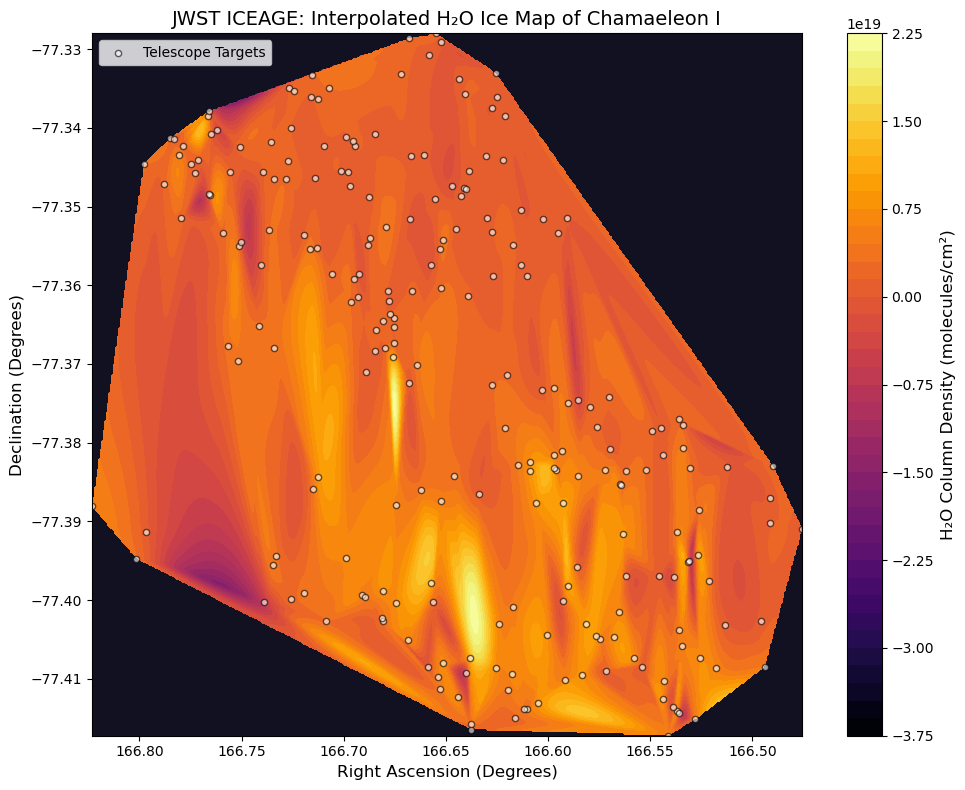

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os 
os.chdir('D:/Astro/data for astroproject 2')

# 1. Load the master catalogue
# (Ensure this file is in your working directory)
file_path = 'IceAge_Complete_Catalogue_V12_Mar24.csv'
catalogue = pd.read_csv(file_path)

# 2. Extract and clean the Column Density data
# The CSV stores these numbers as scientific notation strings (e.g., '4.90E+18')
# We convert them to actual floats and drop any stars missing H2O data
catalogue['H2O_numeric'] = pd.to_numeric(catalogue['H2O_N'], errors='coerce')
clean_df = catalogue.dropna(subset=['RA', 'Dec', 'H2O_numeric'])

ra = clean_df['RA'].values
dec = clean_df['Dec'].values
h2o_values = clean_df['H2O_numeric'].values

# 3. Create the 2D Spatial Grid (The "Canvas")
# This creates a dense 500x500 matrix of pixels covering the exact boundaries of the cloud
grid_ra, grid_dec = np.mgrid[ra.min():ra.max():500j, dec.min():dec.max():500j]

# 4. Perform the Spatial Interpolation
# This magically blends the empty space between the scattered stars using a cubic spline
# (the 2D equivalent of natural neighbor mapping)
grid_h2o = griddata((ra, dec), h2o_values, (grid_ra, grid_dec), method='cubic')

# 5. Build the Heat Map Plot
plt.figure(figsize=(10, 8))

# Draw the interpolated color map using a vibrant heatmap palette ('inferno')
# We use contourf to create smooth, filled contour zones of ice
heatmap = plt.contourf(grid_ra, grid_dec, grid_h2o, levels=50, cmap='inferno')

# Add a color bar so the group can read the physical values
cbar = plt.colorbar(heatmap)
cbar.set_label('H₂O Column Density (molecules/cm²)', fontsize=12)

# Overlay the original stars as small white dots to show where the real data is
plt.scatter(ra, dec, color='white', edgecolor='black', s=20, alpha=0.6, label='Telescope Targets')

# CRUCIAL ASTRONOMY RULE: Invert the X-axis because Right Ascension increases to the left
plt.gca().invert_xaxis()

# Format the map
plt.xlabel('Right Ascension (Degrees)', fontsize=12)
plt.ylabel('Declination (Degrees)', fontsize=12)
plt.title('JWST ICEAGE: Interpolated H₂O Ice Map of Chamaeleon I', fontsize=14)
plt.legend(loc='upper left')

# Use a dark background so the space outside the interpolation boundary stays black
plt.gca().set_facecolor('#111122') 

plt.tight_layout()
plt.show()

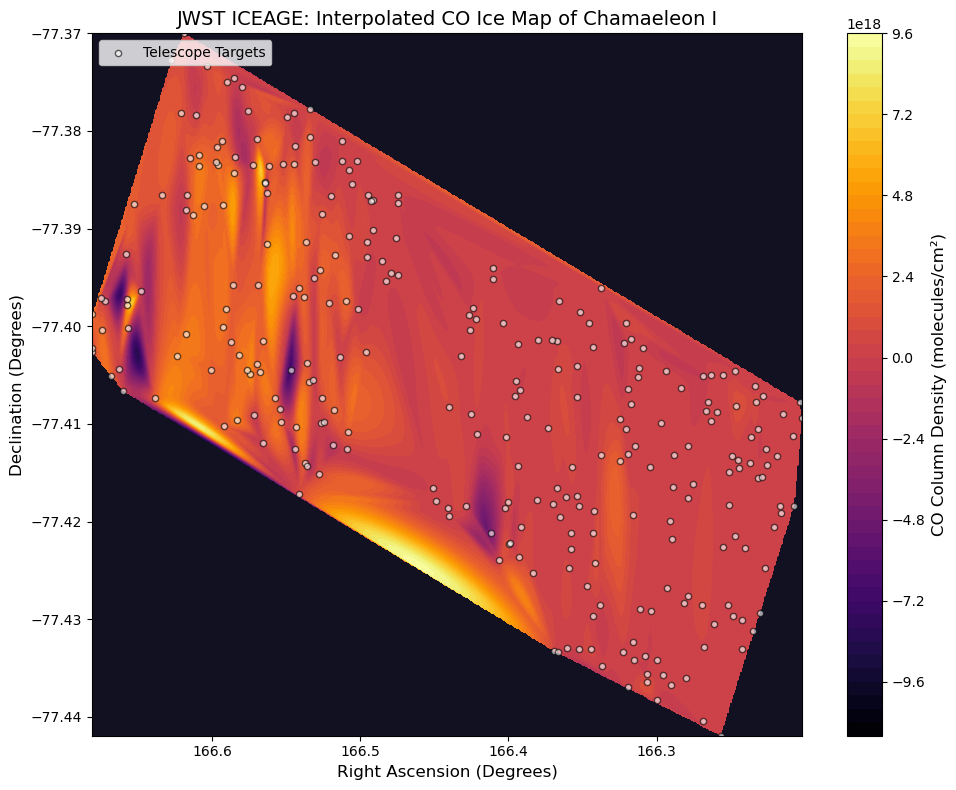

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os 
os.chdir('D:/Astro/data for astroproject 2')

# 1. Load the master catalogue
# (Ensure this file is in your working directory)
file_path = 'IceAge_Complete_Catalogue_V12_Mar24.csv'
catalogue = pd.read_csv(file_path)

# 2. Extract and clean the Column Density data
# The CSV stores these numbers as scientific notation strings (e.g., '4.90E+18')
# We convert them to actual floats and drop any stars missing H2O data
catalogue['CO_numeric'] = pd.to_numeric(catalogue['CO_N'], errors='coerce')
clean_df = catalogue.dropna(subset=['RA', 'Dec', 'CO_numeric'])

ra = clean_df['RA'].values
dec = clean_df['Dec'].values
h2o_values = clean_df['CO_numeric'].values

# 3. Create the 2D Spatial Grid (The "Canvas")
# This creates a dense 500x500 matrix of pixels covering the exact boundaries of the cloud
grid_ra, grid_dec = np.mgrid[ra.min():ra.max():500j, dec.min():dec.max():500j]

# 4. Perform the Spatial Interpolation
# This magically blends the empty space between the scattered stars using a cubic spline
# (the 2D equivalent of natural neighbor mapping)
grid_h2o = griddata((ra, dec), h2o_values, (grid_ra, grid_dec), method='cubic')

# 5. Build the Heat Map Plot
plt.figure(figsize=(10, 8))

# Draw the interpolated color map using a vibrant heatmap palette ('inferno')
# We use contourf to create smooth, filled contour zones of ice
heatmap = plt.contourf(grid_ra, grid_dec, grid_h2o, levels=50, cmap='inferno')

# Add a color bar so the group can read the physical values
cbar = plt.colorbar(heatmap)
cbar.set_label('CO Column Density (molecules/cm²)', fontsize=12)

# Overlay the original stars as small white dots to show where the real data is
plt.scatter(ra, dec, color='white', edgecolor='black', s=20, alpha=0.6, label='Telescope Targets')

# CRUCIAL ASTRONOMY RULE: Invert the X-axis because Right Ascension increases to the left
plt.gca().invert_xaxis()

# Format the map
plt.xlabel('Right Ascension (Degrees)', fontsize=12)
plt.ylabel('Declination (Degrees)', fontsize=12)
plt.title('JWST ICEAGE: Interpolated CO Ice Map of Chamaeleon I', fontsize=14)
plt.legend(loc='upper left')

# Use a dark background so the space outside the interpolation boundary stays black
plt.gca().set_facecolor('#111122') 

plt.tight_layout()
plt.show()

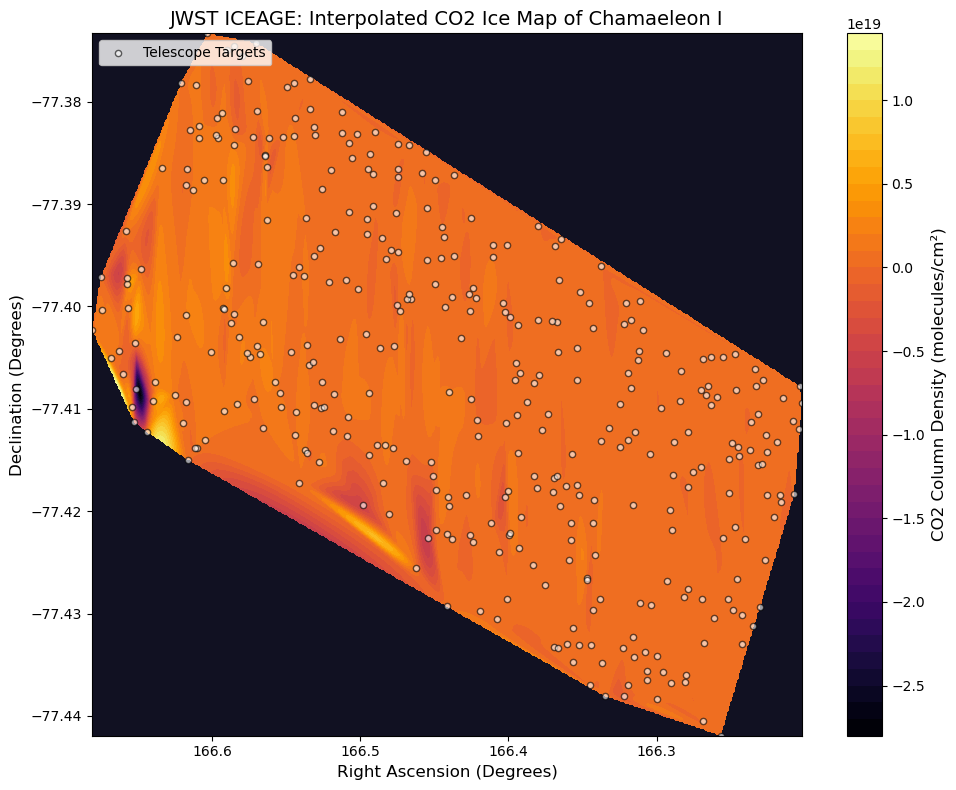

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os 
os.chdir('D:/Astro/data for astroproject 2')

# 1. Load the master catalogue
# (Ensure this file is in your working directory)
file_path = 'IceAge_Complete_Catalogue_V12_Mar24.csv'
catalogue = pd.read_csv(file_path)

# 2. Extract and clean the Column Density data
# The CSV stores these numbers as scientific notation strings (e.g., '4.90E+18')
# We convert them to actual floats and drop any stars missing H2O data
catalogue['CO2_numeric'] = pd.to_numeric(catalogue['CO2_N'], errors='coerce')
clean_df = catalogue.dropna(subset=['RA', 'Dec', 'CO2_numeric'])

ra = clean_df['RA'].values
dec = clean_df['Dec'].values
h2o_values = clean_df['CO2_numeric'].values

# 3. Create the 2D Spatial Grid (The "Canvas")
# This creates a dense 500x500 matrix of pixels covering the exact boundaries of the cloud
grid_ra, grid_dec = np.mgrid[ra.min():ra.max():500j, dec.min():dec.max():500j]

# 4. Perform the Spatial Interpolation
# This magically blends the empty space between the scattered stars using a cubic spline
# (the 2D equivalent of natural neighbor mapping)
grid_h2o = griddata((ra, dec), h2o_values, (grid_ra, grid_dec), method='cubic')

# 5. Build the Heat Map Plot
plt.figure(figsize=(10, 8))

# Draw the interpolated color map using a vibrant heatmap palette ('inferno')
# We use contourf to create smooth, filled contour zones of ice
heatmap = plt.contourf(grid_ra, grid_dec, grid_h2o, levels=50, cmap='inferno')

# Add a color bar so the group can read the physical values
cbar = plt.colorbar(heatmap)
cbar.set_label('CO2 Column Density (molecules/cm²)', fontsize=12)

# Overlay the original stars as small white dots to show where the real data is
plt.scatter(ra, dec, color='white', edgecolor='black', s=20, alpha=0.6, label='Telescope Targets')

# CRUCIAL ASTRONOMY RULE: Invert the X-axis because Right Ascension increases to the left
plt.gca().invert_xaxis()

# Format the map
plt.xlabel('Right Ascension (Degrees)', fontsize=12)
plt.ylabel('Declination (Degrees)', fontsize=12)
plt.title('JWST ICEAGE: Interpolated CO2 Ice Map of Chamaeleon I', fontsize=14)
plt.legend(loc='upper left')

# Use a dark background so the space outside the interpolation boundary stays black
plt.gca().set_facecolor('#111122') 

plt.tight_layout()
plt.show()

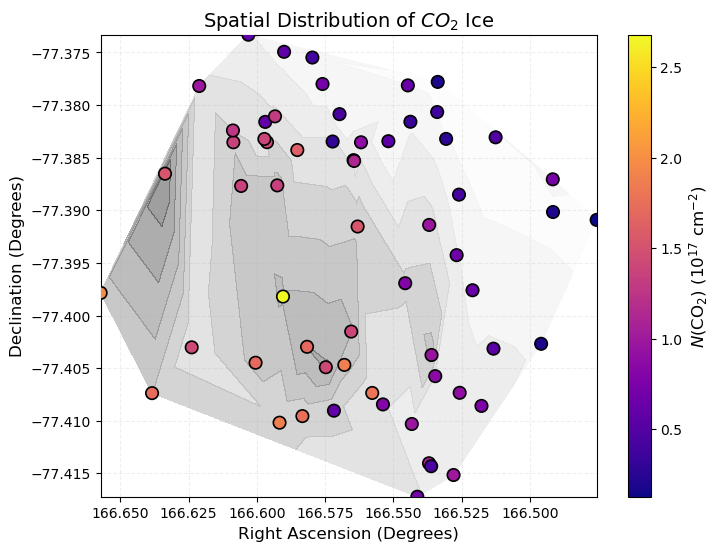

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
df = pd.read_csv('cospatial_map_csv.csv')

# Clean out any negative/zero values
df_clean = df[(df['H2O_N'] > 0) & (df['CO2_N'] > 0) & (df['CO_N'] > 0) & (df['H2_N'] > 0)].copy()

# ==============================================================
# PLOT 1: PUBLICATION-STYLE SPATIAL MAP (Like Screenshot 1)
# ==============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# A. Draw the Gray Background Contours
# We use tricontourf to turn your scattered H2_N data into a smooth, topographical background
# 'Greys' colormap perfectly mimics the Herschel dust maps in the paper
contour = ax.tricontourf(df_clean['RA'], df_clean['Dec'], df_clean['H2_N'], 
                         levels=10, cmap='Greys', alpha=0.4)

# B. Plot the Ice Data on Top
# Using a bright colormap ('plasma' or 'viridis') with bold black edges to make the stars pop
sc = ax.scatter(df_clean['RA'], df_clean['Dec'], 
                c=df_clean['CO2_N'], cmap='plasma', s=80, 
                edgecolor='black', linewidth=1.2, zorder=5, label='JWST Targets')

# C. Formatting
ax.invert_xaxis()  # Right Ascension increases to the left
ax.set_xlabel('Right Ascension (Degrees)', fontsize=12)
ax.set_ylabel('Declination (Degrees)', fontsize=12)
ax.set_title('Spatial Distribution of $CO_2$ Ice', fontsize=14)

# Add Colorbar for the ice
cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label('$N(CO_2)$ Column Density', fontsize=12)
cbar.set_label(r'$N(\mathrm{CO_2})\ (10^{17}\ \mathrm{cm^{-2}})$')
plt.grid(alpha=0.2, linestyle='--')
#plt.savefig('Publication_Spatial_Map.png', dpi=200, bbox_inches='tight')
plt.show()



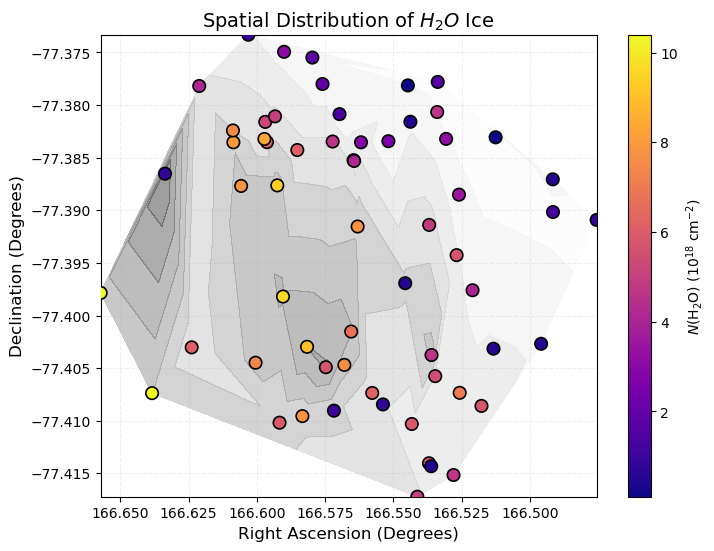

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os 
file_path = r'C:\Users\User\Downloads'
os.chdir(file_path)
# 1. Load the dataset
df = pd.read_csv('cospatial_map_csv.csv')

# Clean out any negative/zero values
df_clean = df[(df['H2O_N'] > 0) & (df['CO2_N'] > 0) & (df['CO_N'] > 0) & (df['H2_N'] > 0)].copy()

# ==============================================================
# PLOT 1: PUBLICATION-STYLE SPATIAL MAP (Like Screenshot 1)
# ==============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# A. Draw the Gray Background Contours
# We use tricontourf to turn your scattered H2_N data into a smooth, topographical background
# 'Greys' colormap perfectly mimics the Herschel dust maps in the paper
contour = ax.tricontourf(df_clean['RA'], df_clean['Dec'], df_clean['H2_N'], 
                         levels=10, cmap='Greys', alpha=0.4)

# B. Plot the Ice Data on Top
# Using a bright colormap ('plasma' or 'viridis') with bold black edges to make the stars pop
sc = ax.scatter(df_clean['RA'], df_clean['Dec'], 
                c=df_clean['H2O_N'], cmap='plasma', s=80, 
                edgecolor='black', linewidth=1.2, zorder=5, label='JWST Targets')

# C. Formatting
ax.invert_xaxis()  # Right Ascension increases to the left
ax.set_xlabel('Right Ascension (Degrees)', fontsize=12)
ax.set_ylabel('Declination (Degrees)', fontsize=12)
ax.set_title('Spatial Distribution of $H_2O$ Ice', fontsize=14)

# Add Colorbar for the ice
cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label('$N(CO_2)$ Column Density', fontsize=12)
cbar.set_label(r'$N(\mathrm{H_2O})\ (10^{18}\ \mathrm{cm^{-2}})$')
plt.grid(alpha=0.2, linestyle='--')
#plt.savefig('Publication_Spatial_Map.png', dpi=200, bbox_inches='tight')
plt.show()
#---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



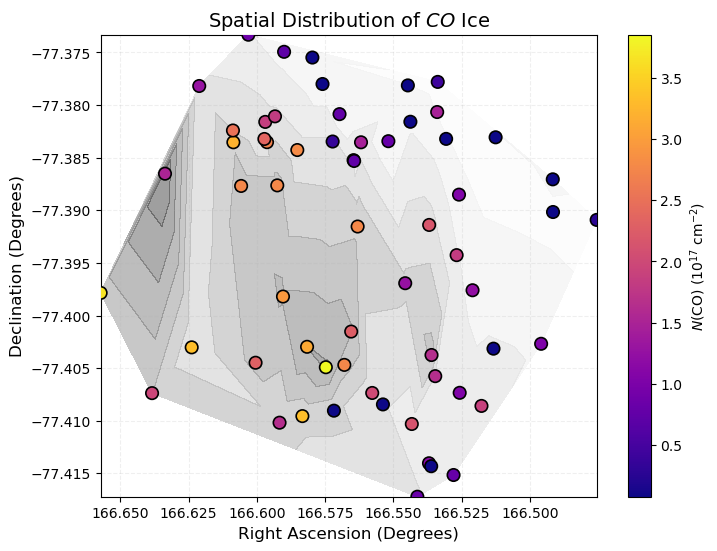

In [11]:
df = pd.read_csv('cospatial_map_csv.csv')

# Clean out any negative/zero values
df_clean = df[(df['H2O_N'] > 0) & (df['CO2_N'] > 0) & (df['CO_N'] > 0) & (df['H2_N'] > 0)].copy()

# ==============================================================
# PLOT 1: PUBLICATION-STYLE SPATIAL MAP (Like Screenshot 1)
# ==============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# A. Draw the Gray Background Contours
# We use tricontourf to turn your scattered H2_N data into a smooth, topographical background
# 'Greys' colormap perfectly mimics the Herschel dust maps in the paper
contour = ax.tricontourf(df_clean['RA'], df_clean['Dec'], df_clean['H2_N'], 
                         levels=10, cmap='Greys', alpha=0.4)
sc = ax.scatter(df_clean['RA'], df_clean['Dec'], 
                c=df_clean['CO_N'], cmap='plasma', s=80, 
                edgecolor='black', linewidth=1.2, zorder=5, label='JWST Targets')

# C. Formatting
ax.invert_xaxis()  # Right Ascension increases to the left
ax.set_xlabel('Right Ascension (Degrees)', fontsize=12)
ax.set_ylabel('Declination (Degrees)', fontsize=12)
ax.set_title('Spatial Distribution of $CO$ Ice', fontsize=14)

# Add Colorbar for the ice
cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label('$N(CO_2)$ Column Density', fontsize=12)
cbar.set_label(r'$N(\mathrm{CO})\ (10^{17}\ \mathrm{cm^{-2}})$')
plt.grid(alpha=0.2, linestyle='--')
#plt.savefig('Publication_Spatial_Map.png', dpi=200, bbox_inches='tight')
plt.show()

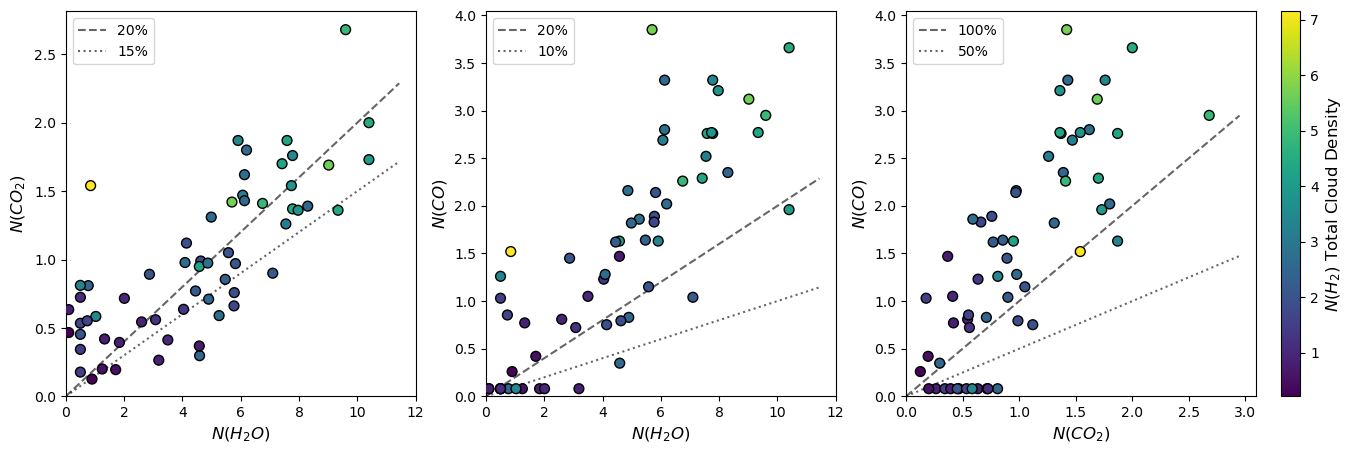

In [6]:
# ==============================================================
# PLOT 2: MULTI-PANEL SCATTER WITH RATIO LINES (Like Screenshot 2)
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# We will color all the scatter dots by the total cloud density (H2_N)
color_data = df_clean['H2_N']

# --- Panel 1: CO2 vs H2O ---
axes[0].scatter(df_clean['H2O_N'], df_clean['CO2_N'], c=color_data, cmap='viridis', 
                s=50, edgecolor='black', zorder=5)
axes[0].set_xlabel('$N(H_2O)$', fontsize=12)
axes[0].set_ylabel('$N(CO_2)$', fontsize=12)

# Draw Constant Ratio Lines (y = mx)
x_vals = np.array([0, df_clean['H2O_N'].max() * 1.1])
axes[0].plot(x_vals, x_vals * 0.20, 'k--', alpha=0.6, label='20%')
axes[0].plot(x_vals, x_vals * 0.15, 'k:', alpha=0.6, label='15%')
axes[0].legend(loc='upper left')
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

# --- Panel 2: CO vs H2O ---
axes[1].scatter(df_clean['H2O_N'], df_clean['CO_N'], c=color_data, cmap='viridis', 
                s=50, edgecolor='black', zorder=5)
axes[1].set_xlabel('$N(H_2O)$', fontsize=12)
axes[1].set_ylabel('$N(CO)$', fontsize=12)

axes[1].plot(x_vals, x_vals * 0.20, 'k--', alpha=0.6, label='20%')
axes[1].plot(x_vals, x_vals * 0.10, 'k:', alpha=0.6, label='10%')
axes[1].legend(loc='upper left')
axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0)

# --- Panel 3: CO vs CO2 ---
sc3 = axes[2].scatter(df_clean['CO2_N'], df_clean['CO_N'], c=color_data, cmap='viridis', 
                      s=50, edgecolor='black', zorder=5)
axes[2].set_xlabel('$N(CO_2)$', fontsize=12)
axes[2].set_ylabel('$N(CO)$', fontsize=12)

x_vals_co2 = np.array([0, df_clean['CO2_N'].max() * 1.1])
axes[2].plot(x_vals_co2, x_vals_co2 * 1.0, 'k--', alpha=0.6, label='100%')
axes[2].plot(x_vals_co2, x_vals_co2 * 0.50, 'k:', alpha=0.6, label='50%')
axes[2].legend(loc='upper left')
axes[2].set_xlim(left=0)
axes[2].set_ylim(bottom=0)

# Add a single colorbar to the entire 3-panel figure
cbar = fig.colorbar(sc3, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('$N(H_2)$ Total Cloud Density', fontsize=12)

#plt.savefig('Publication_Scatter_Plots.png', dpi=200, bbox_inches='tight')
plt.show()